In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight

In [2]:
print(tf.__version__)

2.18.0


In [3]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

In [4]:
X_train, y_train = train["clean_text"].values, train["HATEFUL"].values
X_test, y_test = test["clean_text"].values, test["HATEFUL"].values

In [5]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"
num_classes = 2
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [6]:
max_length= 64
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True,max_length=max_length)
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length = max_length)

In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
))

In [9]:
model_cw = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels = num_classes)

tf_model.h5:   0%|          | 0.00/537M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [11]:
opt = tf.keras.optimizers.AdamW(learning_rate = 2e-5, weight_decay=0.01)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
model_cw.compile(optimizer = opt, loss = loss, metrics = ["accuracy"])

In [ ]:
history_cw = model_cw.fit(train_dataset.batch(16),
          epochs=5,
          validation_data=test_dataset.batch(16),
          class_weight=class_weights)

Epoch 1/5
2103/2103 [==============================] - 606s 262ms/step - loss: 0.5277 - accuracy: 0.7607 - val_loss: 0.4614 - val_accuracy: 0.8140
Epoch 2/5
2103/2103 [==============================] - 545s 259ms/step - loss: 0.3678 - accuracy: 0.8476 - val_loss: 0.3919 - val_accuracy: 0.8411
Epoch 3/5
2103/2103 [==============================] - 542s 258ms/step - loss: 0.2397 - accuracy: 0.8988 - val_loss: 0.4670 - val_accuracy: 0.8417
Epoch 4/5
2103/2103 [==============================] - 542s 258ms/step - loss: 0.1663 - accuracy: 0.9317 - val_loss: 0.5856 - val_accuracy: 0.8133
Epoch 5/5
2103/2103 [==============================] - 572s 272ms/step - loss: 0.1246 - accuracy: 0.9514 - val_loss: 0.5015 - val_accuracy: 0.8497


In [ ]:
y_pred_cw = tf.argmax(model_cw.predict(test_dataset.batch(64)).logits, axis=1)

167/167 [==============================] - 49s 270ms/step


In [ ]:
print(classification_report(y_test, y_pred_cw))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      8961
           1       0.52      0.67      0.58      1682

    accuracy                           0.85     10643
   macro avg       0.73      0.78      0.75     10643
weighted avg       0.87      0.85      0.86     10643



In [ ]:
logits = model_cw.predict(test_dataset.batch(64)).logits
probabilities = tf.nn.softmax(logits).numpy()
y_scores = probabilities[:, 1]

167/167 [==============================] - 44s 265ms/step


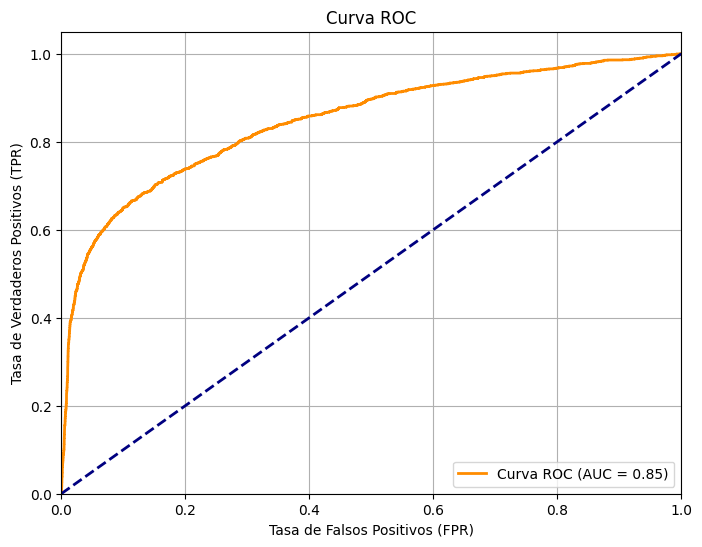

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
